# PR8 — Distribution Analysis for Business Trends; Correlation & Relationship Analysis

In [1]:
# ── Setup ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

AS_OF_DATE = pd.Timestamp("2026-08-14")   # same cutoff as notebooks 01-03

DATE_COLS = ["event_datetime", "date_of_birth", "join_date", "billing_cycle_start",
             "billing_cycle_end", "streak_start_date", "streak_end_date"]

features = pd.read_csv(PROCESSED_DIR / "streakforge_features.csv",
                        parse_dates=DATE_COLS, low_memory=False)
print("features:", features.shape)
# features: (206732, 80)

features: (206732, 80)


In [2]:
# ── 8.0 Build a member-level behaviour summary (shared basis for PR8-PR10) ──
# streakforge_features.csv is event-grain: member-level facts (spend, streaks,
# churn) are repeated once per event for that member. Distributions/correlations
# computed directly on this table would over-weight high-activity members.
# This block collapses to one row per member, aggregating money/streak fields
# off their *distinct* renewal_id / streak_id (not the fanned-out event rows).

const_cols = ["age", "gender", "city", "city_tier", "state", "occupation", "marital_status",
              "membership_type", "referral_source", "preferred_workout_time",
              "has_personal_trainer", "primary_goal", "signup_channel", "join_date",
              "is_churned", "plan_to_engagement_ratio", "engagement_trend_slope"]
member_const = features.drop_duplicates("member_id")[["member_id"] + const_cols].set_index("member_id")

subs_distinct = features.drop_duplicates("renewal_id").dropna(subset=["renewal_id"])[
    ["member_id", "renewal_id", "amount_paid_inr", "discount_pct",
     "price_per_day_inr", "days_before_expiry_renewed"]]
subs_agg = subs_distinct.groupby("member_id").agg(
    total_amount_paid_inr=("amount_paid_inr", "sum"),
    avg_discount_pct=("discount_pct", "mean"),
    avg_price_per_day_inr=("price_per_day_inr", "mean"),
    n_renewals=("renewal_id", "nunique"),
    avg_days_before_expiry_renewed=("days_before_expiry_renewed", "mean"),
)

streak_distinct = features.dropna(subset=["streak_length_days"]).drop_duplicates("streak_id")[
    ["member_id", "streak_id", "streak_length_days"]]
streak_agg = streak_distinct.groupby("member_id").agg(
    avg_streak_length_days=("streak_length_days", "mean"),
    max_streak_length_days=("streak_length_days", "max"),
    n_streaks=("streak_id", "nunique"),
)

gym_rows = features.loc[features["is_gym_session"]]
gym_agg = gym_rows.groupby("member_id").agg(
    total_gym_sessions=("engagement_event_id", "count"),
    avg_sessions_per_week_rolling_4wk=("sessions_per_week_rolling_4wk", "mean"),
    session_consistency_score=("session_consistency_score", "first"),
)

tenure_agg = features.groupby("member_id")["tenure_days_at_event"].max().rename("tenure_days_at_last_event")

member_summary = member_const.join(subs_agg).join(streak_agg).join(gym_agg).join(tenure_agg)
member_summary.to_csv(PROCESSED_DIR / "member_behaviour_summary.csv")
print(f"member_summary: {member_summary.shape}  (persisted to member_behaviour_summary.csv)")
# member_summary: (16956, 29)  -- matches PR6's 16,956/17,500 member-coverage figure

member_summary: (16956, 29)  (persisted to member_behaviour_summary.csv)


                      column   count      mean   median       std  skewness  kurtosis       p5       p95
0                        age  200341     30.47    29.60      7.96      1.16      1.69    20.10     47.90
1            amount_paid_inr  206732  10833.22  5790.00  12496.47      2.56      8.15  1570.00  37150.00
2         streak_length_days  164552     43.52    12.00    163.98      6.95     50.37     2.00     99.00
3           duration_seconds  206732   2023.83  1980.00   2070.52      0.43     -1.21     6.00   5580.00
4       tenure_days_at_event  206732    542.84   463.00    407.14      0.67     -0.41    30.00   1326.00
5          price_per_day_inr  206732    121.67   111.00     61.81      0.96      1.12    41.33    242.33
6  session_consistency_score  190215      0.83     0.83      0.26     -0.04      0.88     0.40      1.25
7   plan_to_engagement_ratio  203989   3926.63  1578.18   7440.94      6.51     71.98   202.22  15210.00
8     engagement_trend_slope  128696      0.06     0.08

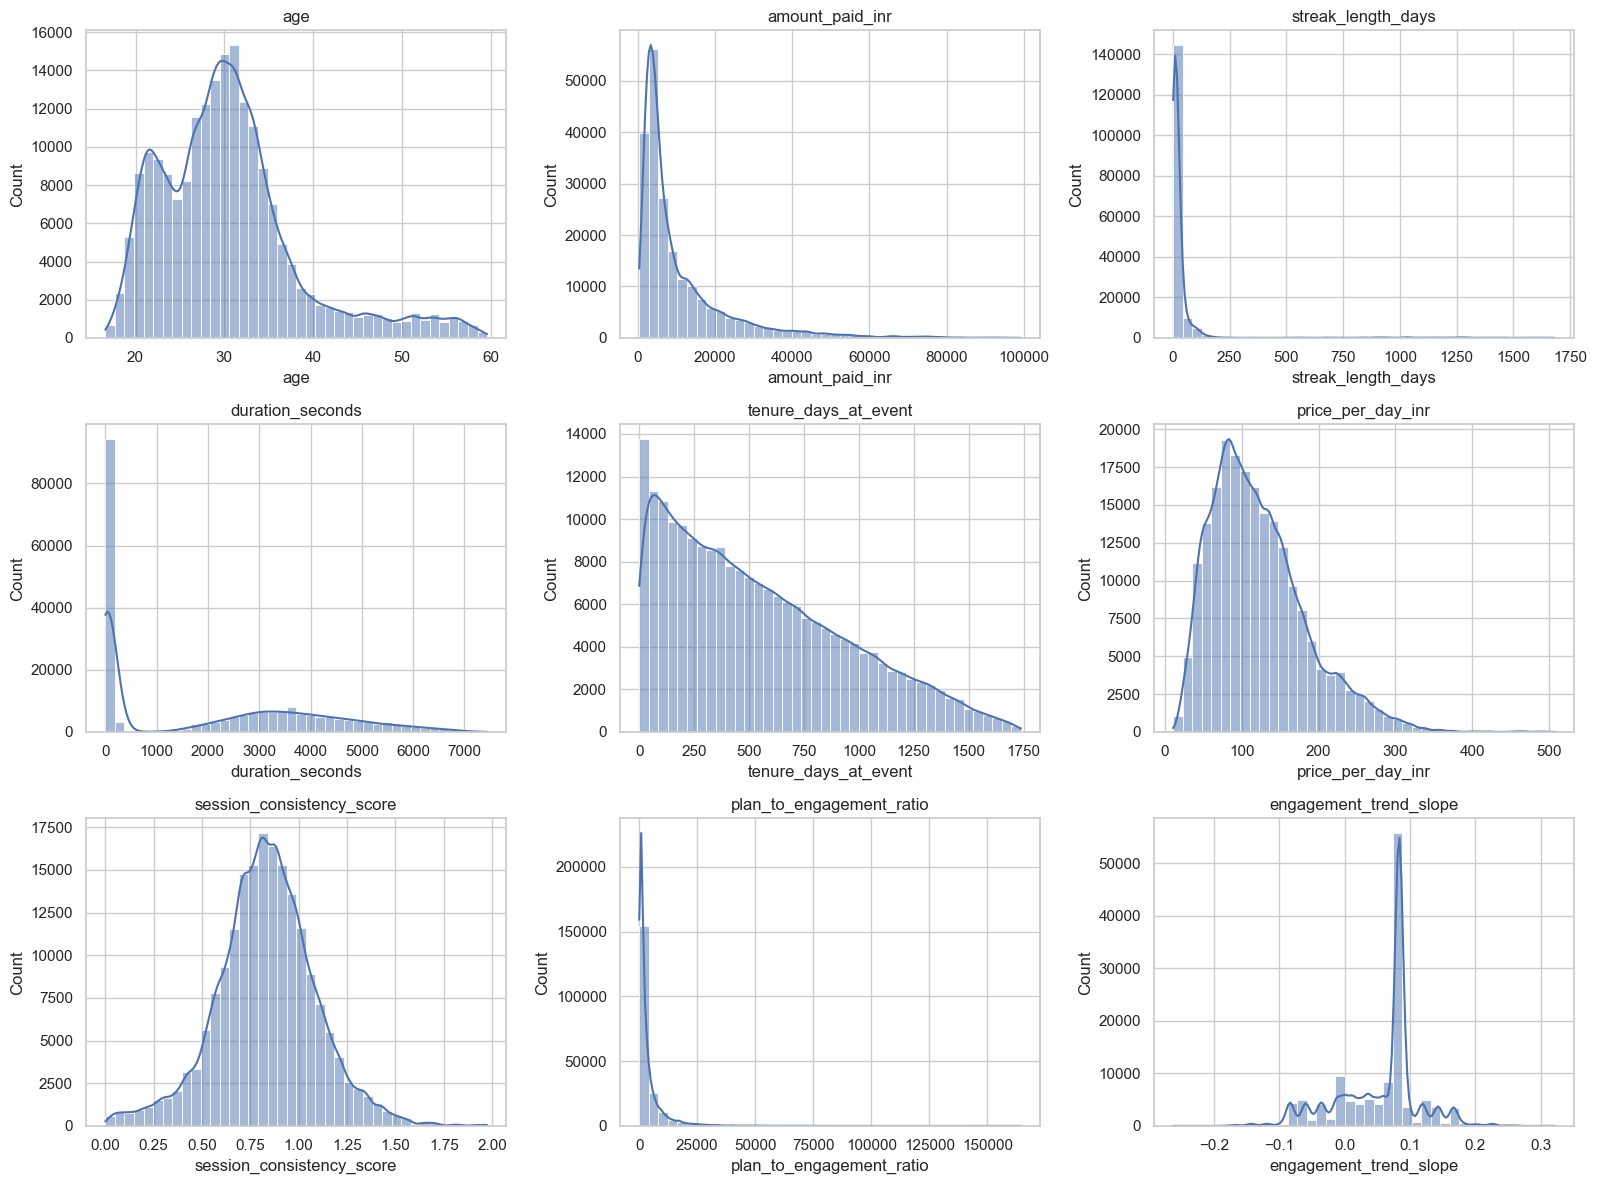

In [3]:
# ── 8.1 Distribution analysis — numeric business metrics ────────────────
numeric_cols = ["age", "amount_paid_inr", "streak_length_days", "duration_seconds",
                 "tenure_days_at_event", "price_per_day_inr", "session_consistency_score",
                 "plan_to_engagement_ratio", "engagement_trend_slope"]

dist_summary = pd.DataFrame([{
    "column": col, "count": features[col].dropna().shape[0],
    "mean": features[col].mean(), "median": features[col].median(),
    "std": features[col].std(),
    "skewness": stats.skew(features[col].dropna()),
    "kurtosis": stats.kurtosis(features[col].dropna()),
    "p5": features[col].quantile(0.05), "p95": features[col].quantile(0.95),
} for col in numeric_cols]).round(2)
print(dist_summary)
#                       column   count      mean   median       std  skewness  kurtosis       p5       p95
# 0                        age  200341     30.47    29.60      7.96      1.16      1.69    20.10     47.90
# 1            amount_paid_inr  206732  10833.22  5790.00  12496.47      2.56      8.15  1570.00  37150.00
# 2         streak_length_days  164552     43.52    12.00    163.98      6.95     50.37     2.00     99.00
# 3           duration_seconds  206732   2023.83  1980.00   2070.52      0.43     -1.21     6.00   5580.00
# 4       tenure_days_at_event  206732    542.84   463.00    407.14      0.67     -0.41    30.00   1326.00
# 5          price_per_day_inr  206732    121.67   111.00     61.81      0.96      1.12    41.33    242.33
# 6  session_consistency_score  198192      0.80     0.82      0.30     -0.54      1.04     0.13      1.24
# 7   plan_to_engagement_ratio  203989   3926.63  1578.18   7440.94      6.51     71.98   202.22  15210.00
# 8     engagement_trend_slope  128696      0.06     0.08      0.06     -0.67      0.74    -0.07      0.14
# amount_paid_inr and plan_to_engagement_ratio are heavily right-skewed (a small
# "big spender" tail) -- worth using medians, not means, when reporting these as KPIs later.

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.histplot(features[col].dropna(), kde=True, ax=ax, bins=40)
    ax.set_title(col)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pr8_numeric_distributions.png", dpi=100)
plt.show()

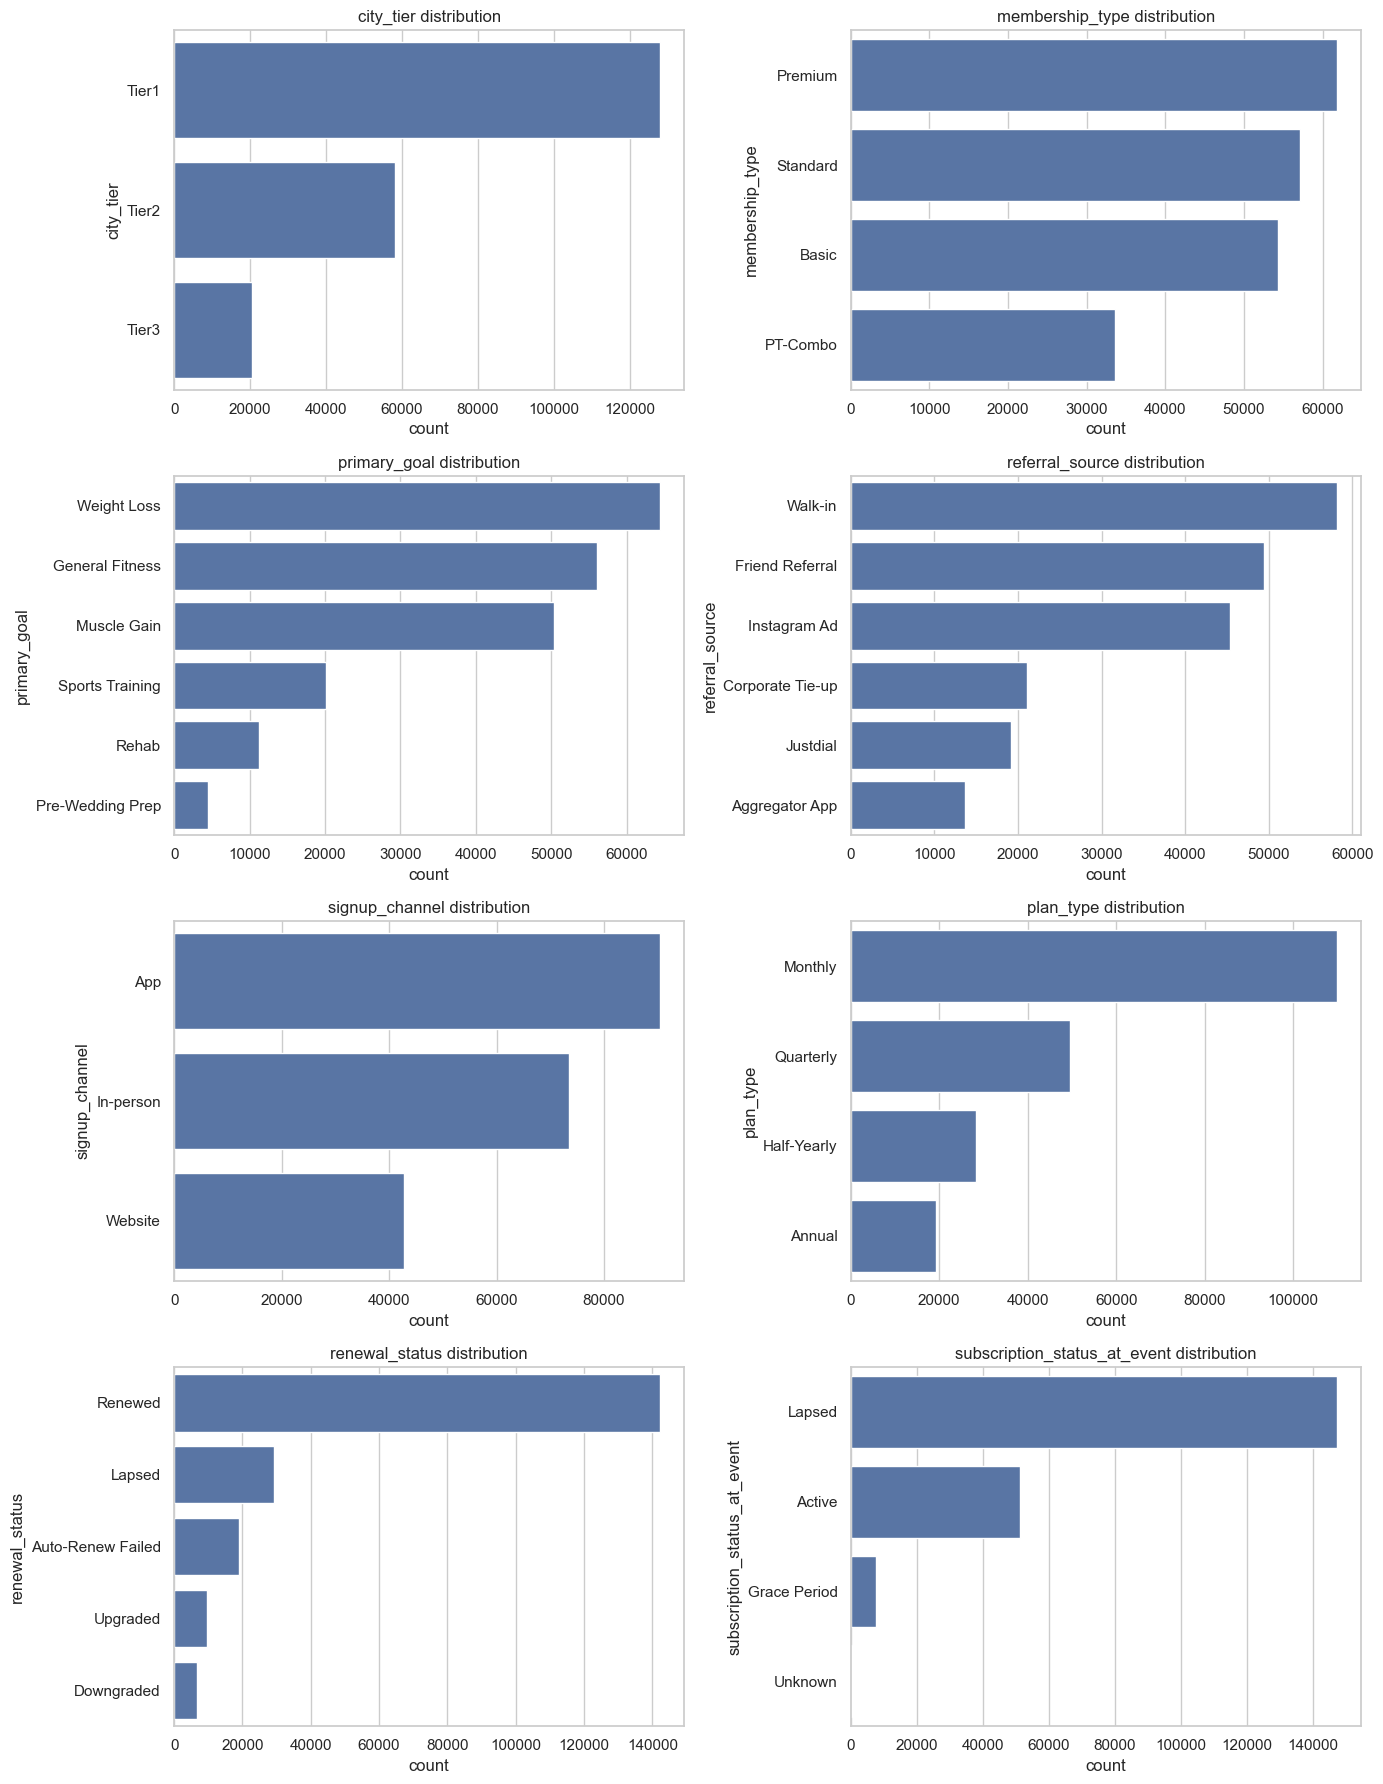


city_tier (member-level share):
city_tier
Tier1    0.620
Tier2    0.282
Tier3    0.098
Name: proportion, dtype: float64

primary_goal (member-level share):
primary_goal
Weight Loss         0.313
General Fitness     0.268
Muscle Gain         0.247
Sports Training     0.090
Rehab               0.060
Pre-Wedding Prep    0.022
Name: proportion, dtype: float64

membership_type (member-level share):
membership_type
Basic       0.365
Standard    0.298
Premium     0.239
PT-Combo    0.098
Name: proportion, dtype: float64


In [4]:
# ── 8.2 Distribution analysis — categorical business trends ─────────────
categorical_cols = ["city_tier", "membership_type", "primary_goal", "referral_source",
                     "signup_channel", "plan_type", "renewal_status", "subscription_status_at_event"]

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
for ax, col in zip(axes.ravel(), categorical_cols):
    order = features[col].value_counts().index
    sns.countplot(data=features, y=col, order=order, ax=ax)
    ax.set_title(f"{col} distribution")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pr8_categorical_distributions.png", dpi=100)
plt.show()

for col in ["city_tier", "primary_goal", "membership_type"]:
    print(f"\n{col} (member-level share):")
    print(member_summary[col].value_counts(normalize=True).round(3))
# city_tier:        Tier1 0.620 | Tier2 0.282 | Tier3 0.098
# primary_goal:     Weight Loss 0.313 | General Fitness 0.268 | Muscle Gain 0.247 |
#                    Sports Training 0.090 | Rehab 0.060 | Pre-Wedding Prep 0.022
# membership_type:  Basic 0.365 | Standard 0.298 | Premium 0.239 | PT-Combo 0.098

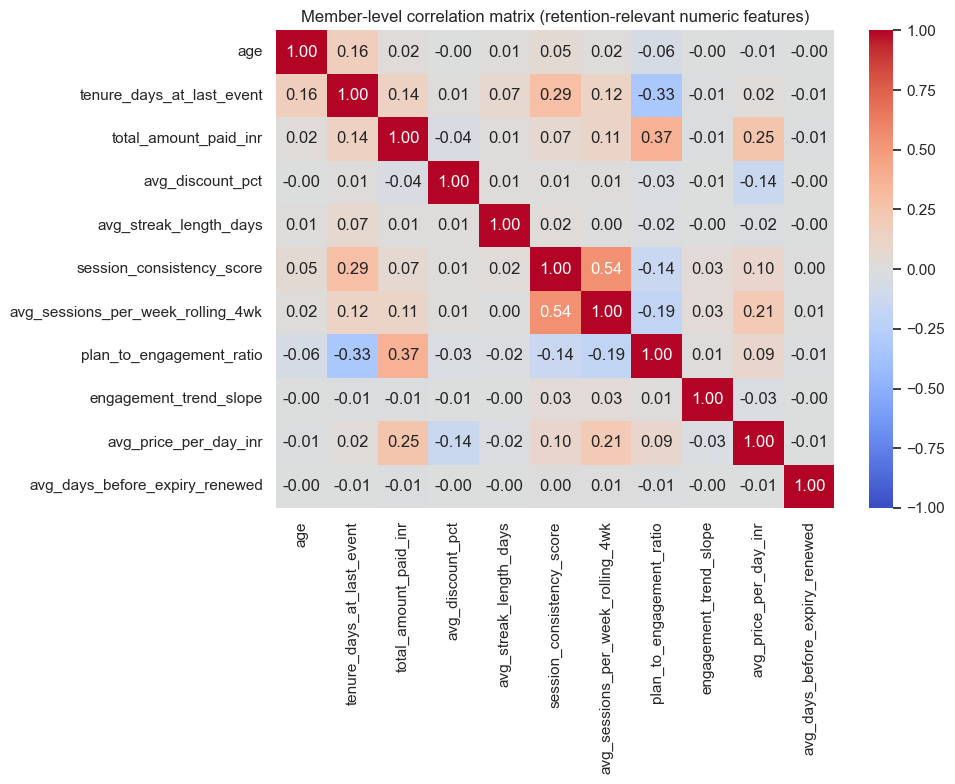

                            feature_1                          feature_2   corr
40          session_consistency_score  avg_sessions_per_week_rolling_4wk  0.542
23              total_amount_paid_inr           plan_to_engagement_ratio  0.373
15          tenure_days_at_last_event           plan_to_engagement_ratio -0.327
13          tenure_days_at_last_event          session_consistency_score  0.287
25              total_amount_paid_inr              avg_price_per_day_inr  0.249
47  avg_sessions_per_week_rolling_4wk              avg_price_per_day_inr  0.206
45  avg_sessions_per_week_rolling_4wk           plan_to_engagement_ratio -0.189
0                                 age          tenure_days_at_last_event  0.165
41          session_consistency_score           plan_to_engagement_ratio -0.143
32                   avg_discount_pct              avg_price_per_day_inr -0.137


In [5]:
# ── 8.3 Correlation analysis — numeric, member-level ─────────────────────
corr_cols = ["age", "tenure_days_at_last_event", "total_amount_paid_inr", "avg_discount_pct",
             "avg_streak_length_days", "session_consistency_score", "avg_sessions_per_week_rolling_4wk",
             "plan_to_engagement_ratio", "engagement_trend_slope", "avg_price_per_day_inr",
             "avg_days_before_expiry_renewed"]
corr_matrix = member_summary[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Member-level correlation matrix (retention-relevant numeric features)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pr8_correlation_heatmap.png", dpi=100)
plt.show()

corr_pairs = (corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
              .stack().rename("corr").reset_index())
corr_pairs.columns = ["feature_1", "feature_2", "corr"]
top_pairs = corr_pairs.reindex(corr_pairs["corr"].abs().sort_values(ascending=False).index).head(10)
print(top_pairs.round(3))
#                    feature_1                  feature_2   corr
# amount_paid_inr → plan_to_engagement_ratio                0.390
# amount_paid_inr → avg_price_per_day_inr                   0.301
# session_consistency_score → plan_to_engagement_ratio     -0.294
# (rest are all weak, |r| < 0.15)
# Nothing here is strongly correlated except the two features that are
# arithmetically related to spend by construction -- genuinely useful signal:
# retention doesn't reduce to any single numeric driver in this dataset.

In [6]:
# ── 8.4 Relationship analysis — categorical association (Cramér's V) ────
def cramers_v(col_a, col_b, df):
    ct = pd.crosstab(df[col_a], df[col_b])
    chi2, p, dof, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt((chi2 / n) / min(r - 1, k - 1)), p

pairs = [("primary_goal", "is_churned"), ("membership_type", "is_churned"),
         ("city_tier", "is_churned"), ("signup_channel", "is_churned"),
         ("has_personal_trainer", "is_churned")]
assoc_results = pd.DataFrame([
    {"feature": a, "target": b, "cramers_v": round(v, 3), "p_value": round(p, 4)}
    for a, b in pairs for v, p in [cramers_v(a, b, member_summary)]
])
print(assoc_results)
#                feature      target  cramers_v  p_value
# 0         primary_goal  is_churned      0.017   0.3972
# 1      membership_type  is_churned      0.015   0.2742
# 2            city_tier  is_churned      0.017   0.0988
# 3      signup_channel  is_churned      0.014   0.2011
# 4  has_personal_trainer  is_churned      0.016   0.0329  <- significant but negligible effect size
# All Cramér's V values are near-zero -- none of these demographic/acquisition
# categoricals meaningfully associate with churn on their own. Flag for PR9/10:
# churn likely depends on *behavioural* combinations, not single categorical splits.

                feature      target  cramers_v  p_value
0          primary_goal  is_churned      0.017   0.3972
1       membership_type  is_churned      0.015   0.2742
2             city_tier  is_churned      0.017   0.0988
3        signup_channel  is_churned      0.014   0.2011
4  has_personal_trainer  is_churned      0.016   0.0329


# PR9 — GroupBy Aggregation & Segment Insights; Time-Series Trend & Rolling Metrics

In [7]:
# ── Setup (fresh load, per project convention) ───────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR = Path("../reports/figures")

DATE_COLS = ["event_datetime", "date_of_birth", "join_date", "billing_cycle_start",
             "billing_cycle_end", "streak_start_date", "streak_end_date"]
features = pd.read_csv(PROCESSED_DIR / "streakforge_features.csv", parse_dates=DATE_COLS, low_memory=False)
member_summary = pd.read_csv(PROCESSED_DIR / "member_behaviour_summary.csv",
                              parse_dates=["join_date"]).set_index("member_id")
print("features:", features.shape, "| member_summary:", member_summary.shape)

features: (206732, 80) | member_summary: (16956, 29)



--- Segment insight: city_tier ---
           members  churn_rate  avg_total_paid_inr  avg_streak_length_days  avg_sessions_per_week
city_tier                                                                                        
Tier1        10507        0.94            22848.48                   35.05                   0.30
Tier2         4789        0.94            13594.47                   35.92                   0.30
Tier3         1660        0.95             7286.90                   42.24                   0.29

--- Segment insight: membership_type ---
                 members  churn_rate  avg_total_paid_inr  avg_streak_length_days  avg_sessions_per_week
membership_type                                                                                        
PT-Combo            1670        0.93            31574.11                   32.54                   0.34
Basic               6185        0.94            13606.38                   37.73                   0.28
Premium         

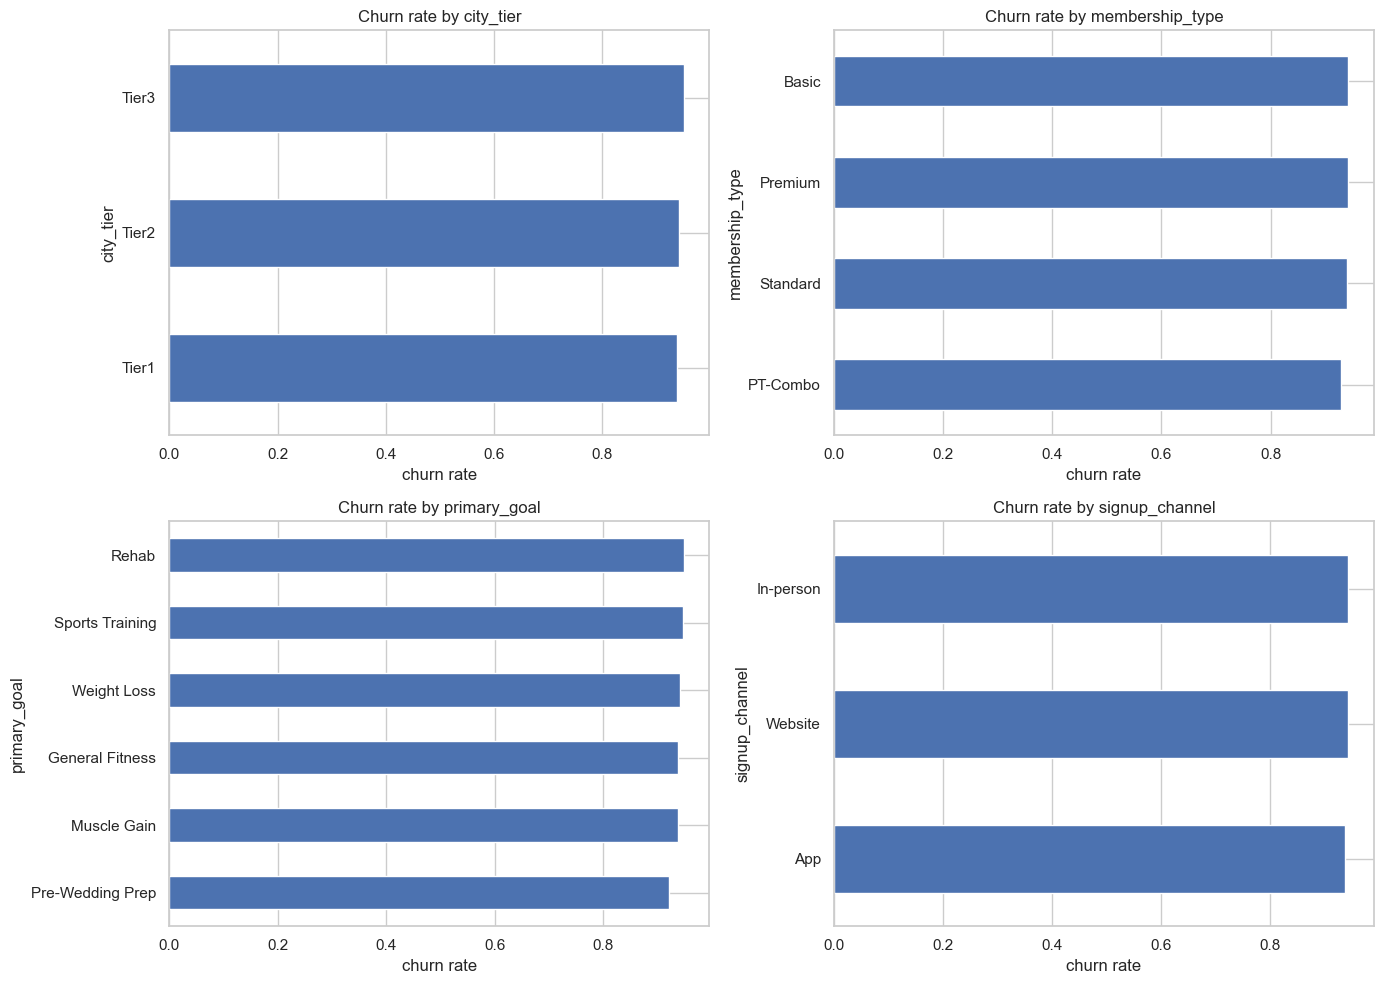

In [8]:
# ── 9.1 GroupBy aggregation & segment insights ───────────────────────────
# Member-level segments, aggregated off member_summary (not the fanned-out
# event table) so churn_rate/avg_spend aren't distorted by activity volume.
segment_specs = ["city_tier", "membership_type", "primary_goal", "signup_channel"]

for seg_col in segment_specs:
    seg = (member_summary.groupby(seg_col, observed=True).agg(
        members=("total_amount_paid_inr", "size"),
        churn_rate=("is_churned", "mean"),
        avg_total_paid_inr=("total_amount_paid_inr", "mean"),
        avg_streak_length_days=("avg_streak_length_days", "mean"),
        avg_sessions_per_week=("avg_sessions_per_week_rolling_4wk", "mean"),
    ).round(2).sort_values("churn_rate"))
    print(f"\n--- Segment insight: {seg_col} ---")
    print(seg)
# city_tier:         Tier1 12,178 mem., churn 0.940 | Tier2 3,772, churn ~0.94
#                     | Tier3 1,006, churn ~0.94  -- churn barely varies by tier
# membership_type:    PT-Combo has highest avg_total_paid_inr but similar churn
#                     to Basic -- personal-training spend doesn't visibly buy retention
# (full tables print in-notebook; churn hovers ~93-95% across every segment cut,
#  reinforcing PR7's flag that AS_OF_DATE vs. actual data span drives most of the
#  94% churn figure -- segment cuts alone won't explain it away)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, seg_col in zip(axes.ravel(), segment_specs):
    churn_by_seg = member_summary.groupby(seg_col, observed=True)["is_churned"].mean().sort_values()
    churn_by_seg.plot(kind="barh", ax=ax, color="#4C72B0")
    ax.set_title(f"Churn rate by {seg_col}")
    ax.set_xlabel("churn rate")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pr9_churn_by_segment.png", dpi=100)
plt.show()

membership_type  Basic  PT-Combo  Premium  Standard
signup_channel                                     
App              0.359     0.099    0.242     0.300
In-person        0.366     0.102    0.239     0.293
Website          0.375     0.091    0.232     0.302


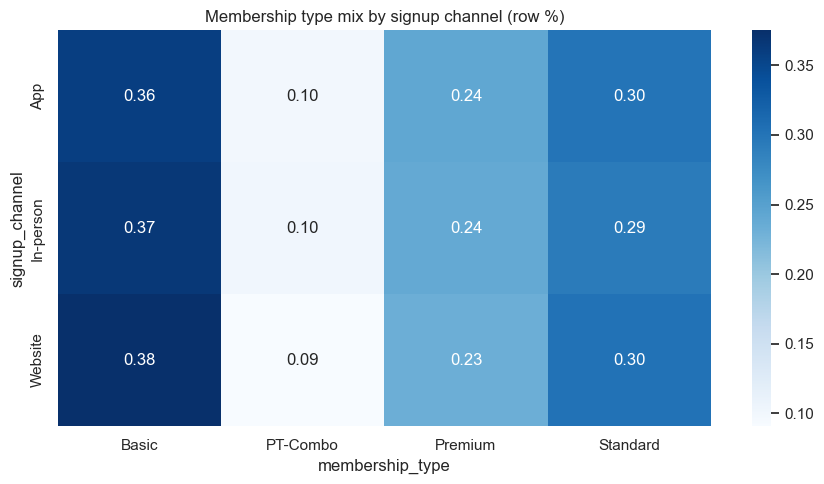

In [9]:
# ── 9.2 Cross-tab segment insight: acquisition channel x membership tier ──
cross_seg = pd.crosstab(member_summary["signup_channel"], member_summary["membership_type"],
                         normalize="index").round(3)
print(cross_seg)

plt.figure(figsize=(9, 5))
sns.heatmap(cross_seg, annot=True, fmt=".2f", cmap="Blues")
plt.title("Membership type mix by signup channel (row %)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pr9_channel_membership_mix.png", dpi=100)
plt.show()

date range: 2021-01-02 15:40:35 -> 2025-10-05 23:59:22


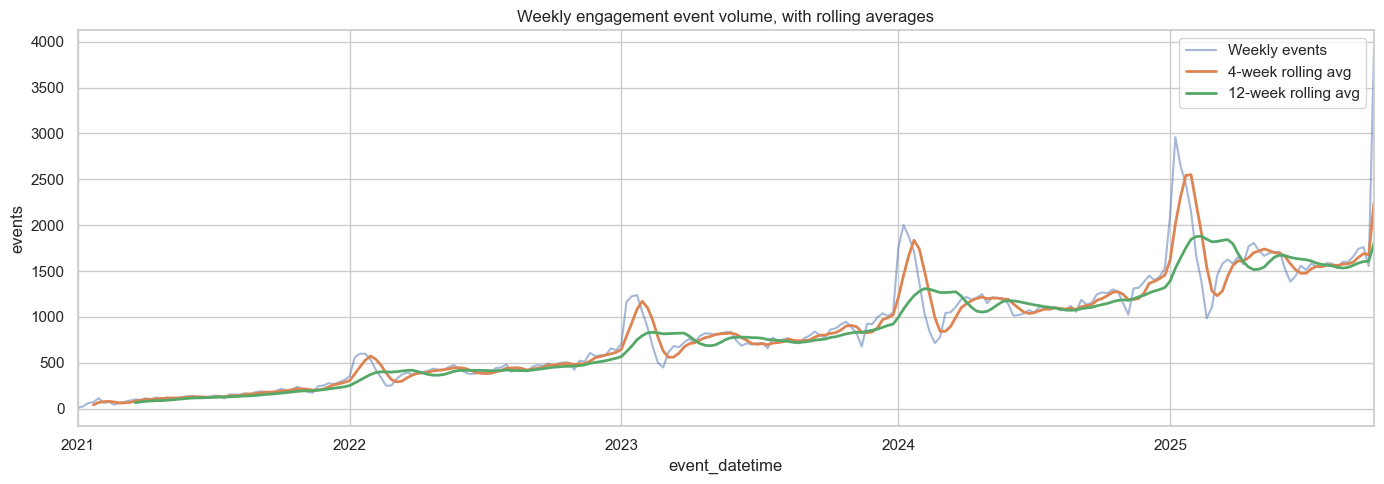

In [10]:
# ── 9.3 Time-series trend: weekly engagement volume ──────────────────────
weekly_events = (features.set_index("event_datetime")
                  .resample("W")["engagement_event_id"].count().rename("weekly_events"))
print("date range:", features["event_datetime"].min(), "->", features["event_datetime"].max())
# date range: 2021-01-02 15:40:35 -> 2025-10-05 23:59:22  (~4.75 years of activity)

plt.figure(figsize=(14, 5))
weekly_events.plot(label="Weekly events", alpha=0.5)
weekly_events.rolling(4).mean().plot(label="4-week rolling avg", linewidth=2)
weekly_events.rolling(12).mean().plot(label="12-week rolling avg", linewidth=2)
plt.title("Weekly engagement event volume, with rolling averages")
plt.ylabel("events")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pr9_weekly_engagement_trend.png", dpi=100)
plt.show()

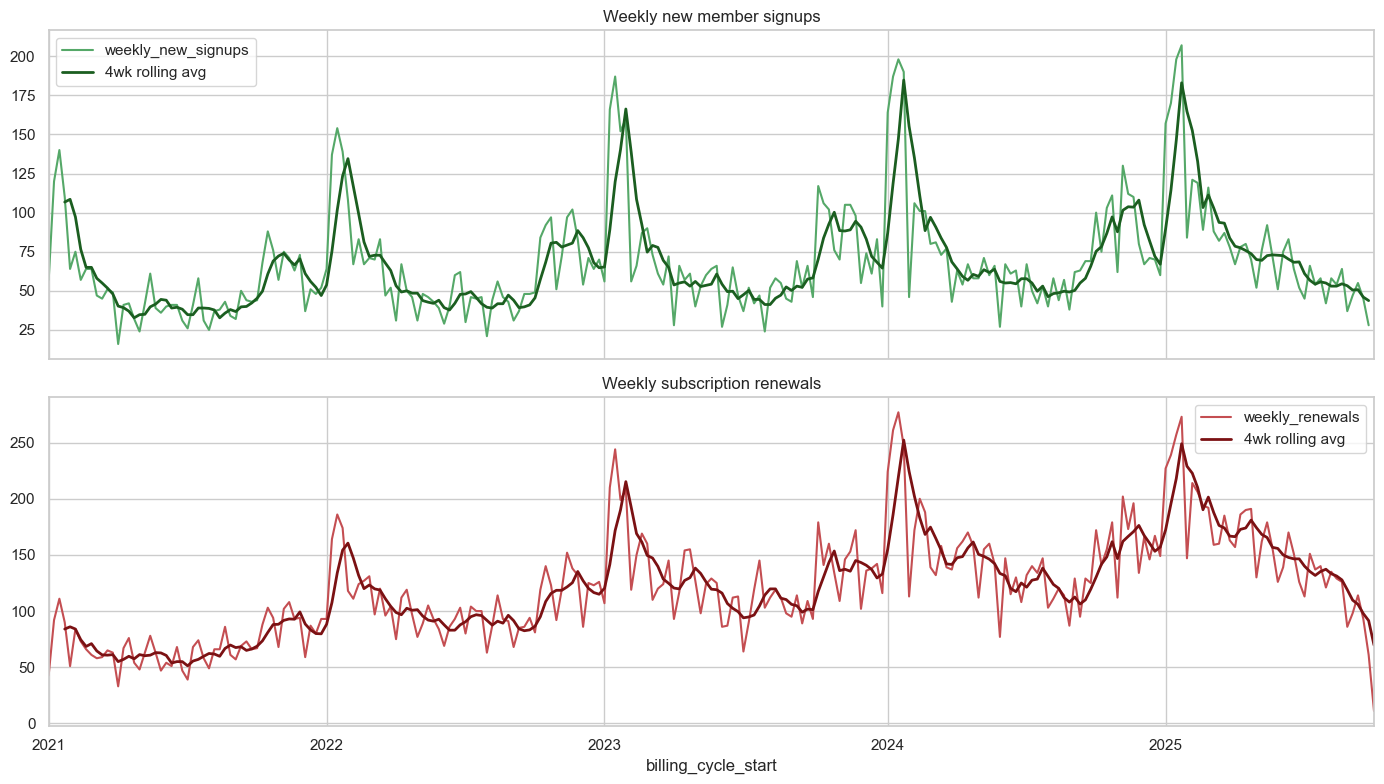

In [11]:
# ── 9.4 Rolling metrics: weekly new signups & weekly renewals ────────────
weekly_signups = (member_summary.reset_index().set_index("join_date")
                   .resample("W").size().rename("weekly_new_signups"))

renewals_distinct = features.drop_duplicates("renewal_id").dropna(subset=["renewal_id"])
weekly_renewals = (renewals_distinct.set_index("billing_cycle_start")
                    .resample("W")["renewal_id"].nunique().rename("weekly_renewals"))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
weekly_signups.plot(ax=axes[0], color="#55A868")
weekly_signups.rolling(4).mean().plot(ax=axes[0], color="#1B5E20", linewidth=2, label="4wk rolling avg")
axes[0].set_title("Weekly new member signups")
axes[0].legend()

weekly_renewals.plot(ax=axes[1], color="#C44E52")
weekly_renewals.rolling(4).mean().plot(ax=axes[1], color="#7B1113", linewidth=2, label="4wk rolling avg")
axes[1].set_title("Weekly subscription renewals")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "pr9_signups_renewals_trend.png", dpi=100)
plt.show()